훈련 데이터 샘플 수: 250, 테스트 데이터 샘플 수: 63

모델 학습 시작...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


모델 학습 완료!
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

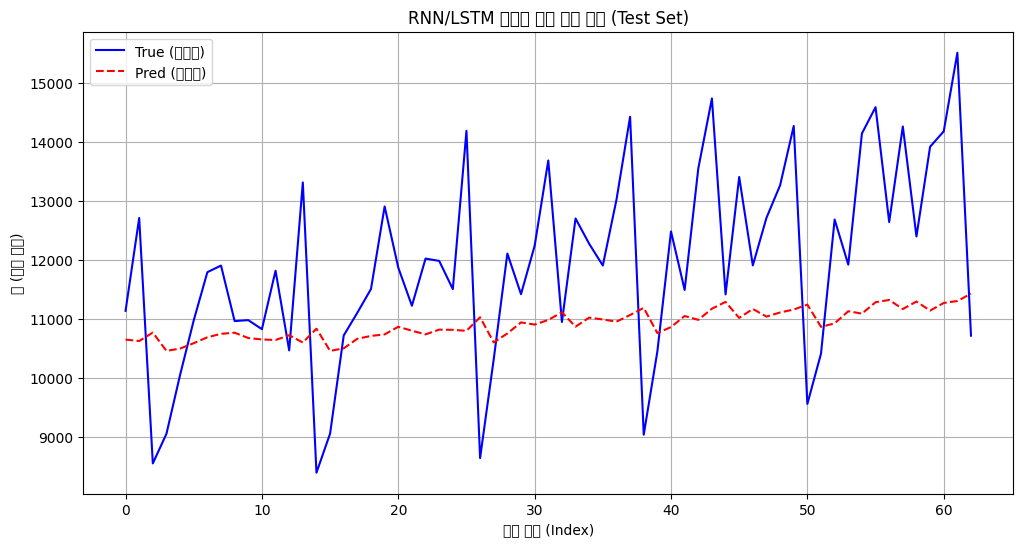


--- 예측 성능 지표 (원래 단위) ---
Mean Squared Error (MSE): 3405341.2620
Root Mean Squared Error (RMSE): 1845.3567
Mean Absolute Error (MAE): 1515.4354


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error # MAE를 위해 추가

# =================================================================
# 1. 데이터 로드 및 전처리
# =================================================================

CSV_FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/Alcohol_Sales.csv'
TARGET_COLUMN = 'S4248SM144NCEN'
TIME_STEPS = 12
TRAIN_RATIO = 0.8

try:
    df = pd.read_csv(CSV_FILE_PATH)
    # 선택된 컬럼만 사용하여 데이터 배열 생성 및 2차원 형태로 변환
    data = df[TARGET_COLUMN].values.reshape(-1, 1)
except FileNotFoundError:
    print(f"오류: {CSV_FILE_PATH} 파일을 찾을 수 없습니다. 경로를 확인해 주세요.")
    exit()
except KeyError:
    print(f"오류: {TARGET_COLUMN} 컬럼을 찾을 수 없습니다. 컬럼 이름을 확인해 주세요.")
    exit()


# 2. 정규화 (MinMaxScaler 사용)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


# =================================================================
# 3. 시퀀스 데이터 생성 함수 (RNN/LSTM 입력 형태)
# =================================================================

def create_sequences(data, time_steps):
    """
    시계열 데이터를 LSTM이 요구하는 시퀀스 (X)와 타겟 (y)으로 변환합니다.
    """
    X, y = [], []
    for i in range(len(data) - time_steps):
        # X: 현재 시점부터 time_steps 길이의 시퀀스 (과거 12개월)
        X.append(data[i:(i + time_steps), 0])
        # y: 바로 다음 시점의 값 (다음 1개월)
        y.append(data[i + time_steps, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, TIME_STEPS)



split_index = int(len(X) * TRAIN_RATIO)

# 과거 데이터(80%)를 학습용으로 사용
Xtrain = X[:split_index]
ytrain = y[:split_index]

# 미래 데이터(20%)를 테스트 및 예측용으로 사용
Xtest = X[split_index:]
ytest = y[split_index:]

# LSTM 입력 형태에 맞게 3차원으로 재구성: (샘플 수, 시퀀스 길이, 특성 수)
Xtrain = Xtrain.reshape(Xtrain.shape[0], Xtrain.shape[1], 1)
Xtest = Xtest.reshape(Xtest.shape[0], Xtest.shape[1], 1)

print(f"훈련 데이터 샘플 수: {Xtrain.shape[0]}, 테스트 데이터 샘플 수: {Xtest.shape[0]}")


# =================================================================
# 5. 모델 구축 및 학습
# =================================================================

# 모델 아키텍처 (업로드된 노트북을 기반으로 작성)
model = Sequential([
    LSTM(units=4, input_shape=(Xtrain.shape[1], Xtrain.shape[2])),
    Dense(units=1)
])

# 모델 컴파일 (손실 함수: MSE 사용)
model.compile(optimizer='adam', loss='mse')

# 모델 학습
print("\n모델 학습 시작...")
history = model.fit(
    Xtrain, ytrain,
    epochs=20,          # 에포크 수 (반복 횟수)
    batch_size=1,       # 배치 사이즈 (노트북과 동일)
    verbose=0
)
print("모델 학습 완료!")


# =================================================================
# 6. 예측 및 결과 시각화
# =================================================================


pred = model.predict(Xtest)

ytest_original = scaler.inverse_transform(ytest.reshape(-1, 1))
pred_original = scaler.inverse_transform(pred)

# 결과 시각화 코드는 동일
plt.figure(figsize=(12, 6))
plt.plot(ytest_original, label='True (실제값)', color='blue')
plt.plot(pred_original, label='Pred (예측값)', color='red', linestyle='--')
plt.title('RNN/LSTM 시계열 예측 결과 비교 (Test Set)')
plt.xlabel('시간 순서 (Index)')
plt.ylabel('값 (원래 단위)')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------------------------------------
# 6. 성능 지표 출력 (변경 지점: MAE 추가)
# -------------------------------------------------------------
# MSE (평균 제곱 오차) 및 RMSE 계산
mse = mean_squared_error(ytest_original, pred_original)
rmse = np.sqrt(mse)

# 💡 MAE (평균 절대 오차) 계산: 새로 추가된 부분
mae = mean_absolute_error(ytest_original, pred_original)

print("\n--- 예측 성능 지표 (원래 단위) ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")